## MODEL FITTING

Importing the needed Libraries

In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from tqdm.notebook import tqdm
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

# Classifiers
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

# Visualization tools
import matplotlib.gridspec as gridspec
from mlxtend.plotting import plot_decision_regions
from mlxtend.preprocessing import shuffle_arrays_unison
import joblib

Loading the dataset

In [2]:
df_original = pd.read_csv('combined_mhealth_data.csv')

In [3]:
df_original

,acc_chest_x,acc_chest_y,acc_chest_z,ecg_1,ecg_2,acc_ankle_x,acc_ankle_y,acc_ankle_z,gyro_ankle_x,gyro_ankle_y,...,acc_arm_x,acc_arm_y,acc_arm_z,gyro_arm_x,gyro_arm_y,gyro_arm_z,magnet_arm_x,magnet_arm_y,magnet_arm_z,label
0,-8.7952,0.36553,-0.90394,0.57352,0.53166,-0.409370,-6.0615,-5.161300,-0.23006,-0.48030,...,-2.04960,-7.8307,-1.06860,-0.46078,-0.37372,-0.056034,-2.9309,-5.83710,12.274,5
1,-8.4579,0.17011,-1.22680,-0.26792,-0.18001,-0.030183,-4.8701,-4.827100,-0.28942,-0.49156,...,-2.07190,-8.4213,-1.12940,-0.47255,-0.36550,-0.043103,-2.7625,-6.94560,10.484,5
2,-8.8564,0.39709,-1.09060,-0.18838,-0.13815,1.045500,-4.8157,-4.344900,-0.28942,-0.49156,...,-2.18990,-8.3788,-0.87727,-0.47255,-0.36550,-0.043103,-2.5611,-4.76270,11.188,5
3,-9.3906,0.33803,-0.76958,-0.18420,-0.14652,1.327300,-4.0696,-3.992300,-0.28942,-0.49156,...,-2.57240,-8.3779,-0.79390,-0.47255,-0.36550,-0.043103,-2.6985,-0.55144,14.753,5
4,-8.8890,0.51293,-1.59590,-0.15489,-0.12559,0.567660,-4.1039,-3.459900,-0.28942,-0.49156,...,-3.45260,-8.4178,-0.77505,-0.47255,-0.36550,-0.043103,-3.8102,-3.99930,13.682,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
343190,-8.6500,-0.83185,-2.23280,0.28885,0.14652,2.767300,-8.9662,0.412700,-0.44341,-0.57974,...,-0.29257,-7.4942,1.58360,-0.72745,-0.61807,-0.165950,13.3000,19.38600,46.282,5
343191,-8.9892,-1.04290,-1.67280,0.44793,0.25955,3.160900,-10.0400,-0.074575,-0.44341,-0.57974,...,-0.51674,-8.0277,1.23400,-0.72745,-0.61807,-0.165950,12.1460,11.72900,41.642,5
343192,-9.4536,-1.05650,-1.77930,0.65306,0.37677,1.928300,-10.0480,-0.889390,-0.44341,-0.57974,...,-0.54466,-8.7792,1.08190,-0.75490,-0.57084,-0.178880,9.7427,4.79500,35.526,5
343193,-10.1930,-1.43780,-1.77150,0.71586,0.42700,2.436800,-9.8005,-1.830200,-0.44341,-0.57974,...,-0.50182,-9.1622,0.78147,-0.75490,-0.57084,-0.178880,7.3557,-0.51279,28.672,5


In [4]:
df_original['label'].value_counts()
# we have 12 class with non equal number 

label
5     30720
1     30720
2     30720
3     30720
4     30720
9     30720
10    30720
11    30720
7     29441
8     29337
6     28315
12    10342
Name: count, dtype: int64

### Balancing the Dataset by Undersampling

The original dataset has an imbalanced distribution of activity labels. To ensure fair training and avoid bias toward dominant classes, we perform class balancing using undersampling.

In [6]:
#  since the data is not balanced, I will take a sample and consider making all the classes of target y the same count
classes = df_original['label'].value_counts()
min_class = classes.min()
df_samples = pd.DataFrame()

for c in classes.index:
    sample = df_original[df_original['label'] == c].sample(min_class, random_state=42)
    df_samples = pd.concat([df_samples, sample])

In [7]:
#  after taking the sample I will shuffle the data to make sure the sample is representative
df = df_samples.sample(frac=1, random_state= None)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 124104 entries, 49287 to 342857
Data columns (total 24 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   acc_chest_x     124104 non-null  float64
 1   acc_chest_y     124104 non-null  float64
 2   acc_chest_z     124104 non-null  float64
 3   ecg_1           124104 non-null  float64
 4   ecg_2           124104 non-null  float64
 5   acc_ankle_x     124104 non-null  float64
 6   acc_ankle_y     124104 non-null  float64
 7   acc_ankle_z     124104 non-null  float64
 8   gyro_ankle_x    124104 non-null  float64
 9   gyro_ankle_y    124104 non-null  float64
 10  gyro_ankle_z    124104 non-null  float64
 11  magnet_ankle_x  124104 non-null  float64
 12  magnet_ankle_y  124104 non-null  float64
 13  magnet_ankle_z  124104 non-null  float64
 14  acc_arm_x       124104 non-null  float64
 15  acc_arm_y       124104 non-null  float64
 16  acc_arm_z       124104 non-null  float64
 17  gyro_arm_x 

In [9]:
df['label'].value_counts()

label
7     10342
8     10342
1     10342
3     10342
4     10342
12    10342
11    10342
6     10342
2     10342
10    10342
5     10342
9     10342
Name: count, dtype: int64

In [10]:
df.shape

(124104, 24)

### Preparing the Final Dataset for Model Training

Now that we've completed data cleaning, transformation, and balancing, we prepare our features (`X`) and target (`y`) for modeling.

In [11]:
# select all rows and columns except the last one.
x = df.iloc[:,:-1]
# select all rows, but only the last column.
y = df.iloc[:,-1]
print(y)
x

49287      7
123518     8
177297     1
42533      3
220517     4
          ..
17661      6
200733    10
168524    10
93306      8
342857     5
Name: label, Length: 124104, dtype: int64


,acc_chest_x,acc_chest_y,acc_chest_z,ecg_1,ecg_2,acc_ankle_x,acc_ankle_y,acc_ankle_z,gyro_ankle_x,gyro_ankle_y,...,magnet_ankle_z,acc_arm_x,acc_arm_y,acc_arm_z,gyro_arm_x,gyro_arm_y,gyro_arm_z,magnet_arm_x,magnet_arm_y,magnet_arm_z
49287,-8.9621,0.12521,3.76920,-0.694920,-0.552590,2.58360,-9.5359,0.86154,-0.35250,-0.79550,...,0.11075,-0.55366,5.2371,4.709800,-0.364710,1.03490,0.14871,-44.34000,18.37600,-21.64800
123518,-6.2491,1.34200,-11.15300,-2.394600,-0.602830,1.69770,-6.8175,-8.48010,-0.26160,-0.10507,...,-1.44160,-2.11500,-10.5470,6.347700,-0.523530,-0.94867,0.22845,-1.92310,41.08500,4.96580
177297,-9.7806,-0.86912,-0.64664,-0.138150,-0.054422,2.18510,-9.6165,0.72853,0.75696,-0.63790,...,-1.01440,-2.26350,-9.5902,-0.021177,0.421570,-1.00620,0.40302,0.36433,0.52640,-1.44200
42533,2.5572,0.42456,9.59610,-0.071167,-0.087912,3.68580,1.5045,8.86210,0.39332,0.65291,...,-0.58665,-7.43900,1.3552,6.515700,-0.209800,0.70431,0.76078,0.54214,0.35402,-0.35371
220517,-12.1430,-0.40915,-1.53160,-0.196760,-0.025118,1.87750,-6.4788,-0.35725,-0.09462,-0.37148,...,14.75600,-2.98210,-10.8270,1.344100,0.468630,-1.02870,-0.14224,-0.34671,-16.71800,142.76000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17661,-5.4420,3.92060,-5.58400,-0.205130,-0.293040,-0.90647,-9.6462,0.72738,0.09462,-0.85178,...,1.89540,-3.42730,-8.3298,0.021011,0.274510,-1.05130,-0.34914,12.19600,-1.25360,32.02500
200733,-4.3929,-3.58790,-0.14397,1.348000,0.071167,-2.11590,-19.4140,-14.67900,-0.17440,-0.69231,...,-2.57640,-5.92280,-9.5406,-2.060400,-0.701960,-0.67351,-0.21121,-39.27400,-31.57600,197.00000
168524,-21.7320,-7.86390,-6.04460,0.313970,0.293040,-18.16500,-5.2429,-8.44380,-0.24119,-0.79550,...,-23.38800,-9.21310,-11.7100,1.008300,-0.964710,-0.15195,-0.36853,70.39500,37.69800,-188.86000
93306,-9.6442,-0.61651,0.49188,-0.276300,-0.062794,1.32850,-9.5062,-0.12869,-0.41558,-0.82552,...,1.32890,-2.86300,-8.9492,3.083800,-0.086275,-1.08620,-0.37931,1.60190,-1.39430,-10.78400


In [12]:
# Scaling:
scaler = StandardScaler()
X = scaler.fit_transform(x)
# Splitting
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, train_size= 0.8, random_state=None, shuffle=True)

In [13]:
#check the traing set and test set shapes:
print(x_train.shape, x_test.shape, y_train.shape, y_test.shape)

(99283, 23) (24821, 23) (99283,) (24821,)


### K-Nearest Neighbors (KNN) Classifier

We now train a **K-Nearest Neighbors (KNN)** model on our processed dataset.

In [15]:
hyperParam_K = [3,5,7]
accuracies = []
for i in hyperParam_K:
  knn = KNeighborsClassifier(n_neighbors= i)
  knn.fit(x_train, y_train)
  y_pred = knn.predict(x_test)
  accuracies.append((accuracy_score(y_test, y_pred)))

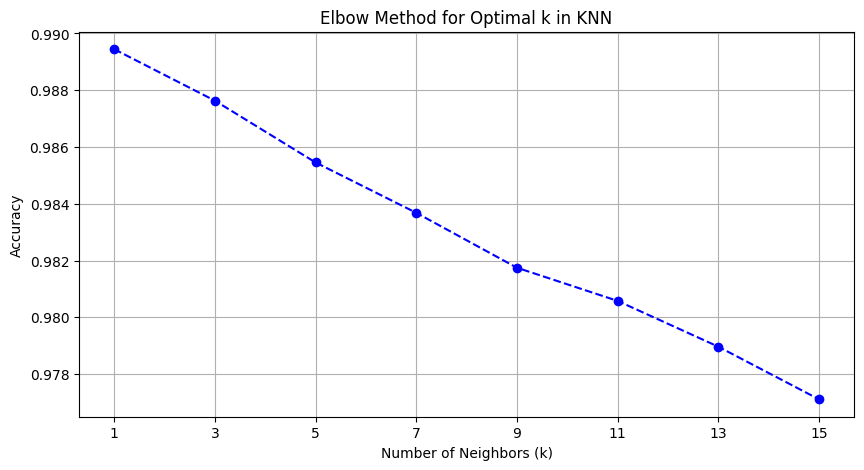

In [16]:
# Define range of K values to test
hyperParam_K = [1, 3, 5, 7, 9, 11, 13, 15]
accuracies = []

# Loop through and record accuracy
for k in hyperParam_K:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(x_train, y_train)
    y_pred = knn.predict(x_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

# Plotting the Elbow Curve
plt.figure(figsize=(10, 5))
plt.plot(hyperParam_K, accuracies, marker='o', linestyle='--', color='b')
plt.title('Elbow Method for Optimal k in KNN')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.xticks(hyperParam_K)
plt.grid(True)
plt.show()

In [17]:
accuracies

[0.9894444220619637,
 0.9876314411184078,
 0.9854558639861408,
 0.9836831715079972,
 0.9817493251682043,
 0.9805809596712461,
 0.978969421054752,
 0.9771161516457838]

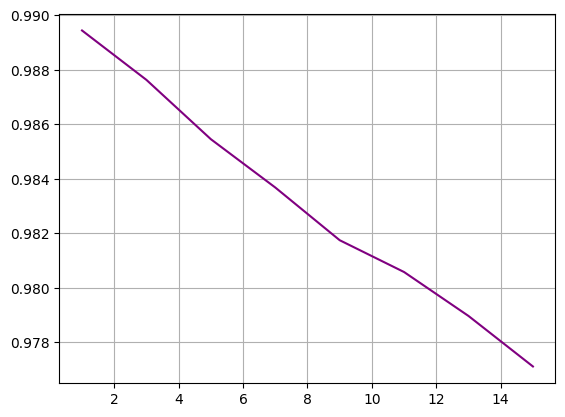

In [18]:
plt.plot(hyperParam_K, accuracies, color='purple')
plt.grid(True)
plt.show()     

In [19]:
#  3 is the best
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(x_train, y_train)

knn_predictions = knn.predict(x_test)
print(f'The accuracy of the model :{accuracy_score(y_test, knn_predictions)}')

The accuracy of the model :0.9876314411184078


### Support Vector Machine (SVM) Classifier

We now apply a **Support Vector Machine (SVM)** model to classify the activity data based on sensor readings.


In [23]:
svm = SVC(C=100, kernel='rbf')
svm.fit(x_train, y_train)

SVC(C=100)

In [41]:
svm = SVC(C=100, kernel='rbf', probability=True)
svm.fit(x_train, y_train)

SVC(C=100, probability=True)

In [25]:
x_train_np = np.array(x_train)
y_train_np = np.array(y_train)

In [26]:
svm_predictions = svm.predict(x_test)
accuracy = np.mean(svm_predictions == y_test)
print("The accuracy of the model", accuracy*100,"%")

The accuracy of the model 99.4399903307683 %


### Linear Regression

Although Linear Regression is traditionally used for **regression tasks** (predicting continuous values), it can also be explored for **multi-class classification problems** as a baseline or for comparison.

In [33]:
lr = LinearRegression()
model_lr= lr.fit(x_train, y_train)
model_lr.predict(x_test)

array([7.12013854, 5.93530745, 7.03805471, ..., 4.24272745, 5.86556912,
       7.11494366])

In [34]:
lr.score(x_train,y_train)

0.43511163833848054

### Logistic Regression Classifier

Next, we apply a **Logistic Regression** model to our sensor dataset for multi-class activity classification.

In [29]:
# set > multi_class='ovr'  for 1 vs all
lm = linear_model.LogisticRegression(multi_class='ovr', solver='liblinear')
lm.fit(x_train, y_train)

LogisticRegression(multi_class='ovr', solver='liblinear')

Hyperparameter tuning + Cross Validation

In [30]:
params = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}
grid_search = model_selection.GridSearchCV(lm, params, cv=5)
grid_search.fit(x_train, y_train)

print("Best c:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)

logistic_predictions = grid_search.score(x_test, y_test)
print("Test Accuracy:", logistic_predictions)

Best c: {'C': 0.1}
Best cross-validation score: 0.6562754658743133
Test Accuracy: 0.6559767938439225


In [31]:
lm.score(x_train, y_train)

0.6566884562311776

### Decision Tree Classifier

The **Decision Tree Classifier** is a versatile, non-parametric supervised learning algorithm that works by recursively splitting the data into subsets based on feature values. 

In [38]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(x_train, y_train)

DecisionTreeClassifier(random_state=42)

In [39]:
dt_preds = dt.predict(x_test)

# Calculate accuracy
dt_acc = accuracy_score(y_test, dt_preds)
print("DecisionTree Accuracy:", dt_acc)

DecisionTree Accuracy: 0.9537891301720317


### Random Forest Classifier

Random Forest is an **ensemble learning method** that builds multiple decision trees and merges their results to get more accurate and stable predictions.

In [36]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(x_train, y_train)

RandomForestClassifier(random_state=42)

In [37]:
rf_preds = rf.predict(x_test)

# Calculate accuracy
rf_acc = accuracy_score(y_test, rf_preds)
print("Random Forest Test Accuracy:", rf_acc)

Random Forest Test Accuracy: 0.9952056726159301


### Multi-Layer Perceptron (MLP) Classifier

The **Multi-layer Perceptron (MLP)** is a type of **artificial neural network** used for supervised learning tasks. It consists of at least three layers of nodes: an input layer, a hidden layer, and an output layer.

In [40]:
mlp = MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42)
mlp.fit(x_train, y_train)

MLPClassifier(max_iter=300, random_state=42)

In [42]:
mlp_preds = mlp.predict(x_test)
mlp_acc = accuracy_score(y_test, mlp_preds)
print("MLP Classifier Test Accuracy:", mlp_acc)

MLP Classifier Test Accuracy: 0.9906933644897465


## Results

In [43]:
# KNN
knn_accuracy = accuracy_score(y_test, knn_predictions)
print("KNN Accuracy:", knn_accuracy)

# SVM
svm_accuracy = accuracy_score(y_test, svm_predictions)
print("SVM Accuracy:", svm_accuracy)

# Logistic Regression
print("Logistic Regression Accuracy:", logistic_predictions)

# Random Forest
rf_accuracy = accuracy_score(y_test, rf_preds)
print("Random Forest Accuracy:", rf_accuracy)

# Decision Tree
dt_accuracy = accuracy_score(y_test, dt_preds)
print("Decision Tree Accuracy:", dt_accuracy)

# MLP (Neural Network)
mlp_accuracy = accuracy_score(y_test, mlp_preds)
print("MLP Classifier Accuracy:", mlp_accuracy)

KNN Accuracy: 0.9876314411184078
SVM Accuracy: 0.994399903307683
Logistic Regression Accuracy: 0.6559767938439225
Random Forest Accuracy: 0.9952056726159301
Decision Tree Accuracy: 0.9537891301720317
MLP Classifier Accuracy: 0.9906933644897465


In [45]:
# KNN
knn_conf_mat = confusion_matrix(y_test, knn_predictions)
print("KNN Confusion Matrix:\n", knn_conf_mat)
print("_______________________________________________________________________")

# SVM
svm_conf_mat = confusion_matrix(y_test, svm_predictions)
print("SVM Confusion Matrix:\n", svm_conf_mat)
print("_______________________________________________________________________")

# Logistic Regression
log_conf_mat = confusion_matrix(y_test, grid_search.predict(x_test))
print("Logistic Regression Confusion Matrix:\n", log_conf_mat)
print("_______________________________________________________________________")

# Random Forest
rf_conf_mat = confusion_matrix(y_test, rf_preds)
print("Random Forest Confusion Matrix:\n", rf_conf_mat)
print("_______________________________________________________________________")

# Decision Tree
dt_conf_mat = confusion_matrix(y_test, dt_preds)
print("Decision Tree Confusion Matrix:\n", dt_conf_mat)
print("_______________________________________________________________________")

# MLP
mlp_conf_mat = confusion_matrix(y_test, mlp_preds)
print("MLP Classifier Confusion Matrix:\n", mlp_conf_mat)
print("_______________________________________________________________________")


KNN Confusion Matrix:
 [[2019    0    0    0    0    0    0    0    0    0    0    0]
 [   0 2049    0    0    0    0    0    0    0    0    0    0]
 [   0    0 2067    0    0    0    0    0    0    0    0    0]
 [   1    0    0 2059    1    0    0    0    0    0    0    0]
 [   5    1    0   30 2019    4    2   16    0    0    0    0]
 [   6    0    0    0    0 2073   13    2    0    0    0    0]
 [   1    0    0    0    0   11 2094    7    0    0    0    0]
 [   2    0    0    0    0    8    4 2112    1    0    0    0]
 [   0    0    0    0    0    0    0    0 2071    0    0    0]
 [   0    0    0    3    0    0    0    1    0 2055   26    3]
 [   0    0    0    2    0    0    0    0    0   80 1927    3]
 [   0    1    0   14    9    1    3    1    0   35   10 1969]]
_______________________________________________________________________
SVM Confusion Matrix:
 [[2019    0    0    0    0    0    0    0    0    0    0    0]
 [   0 2049    0    0    0    0    0    0    0    0    0    0]

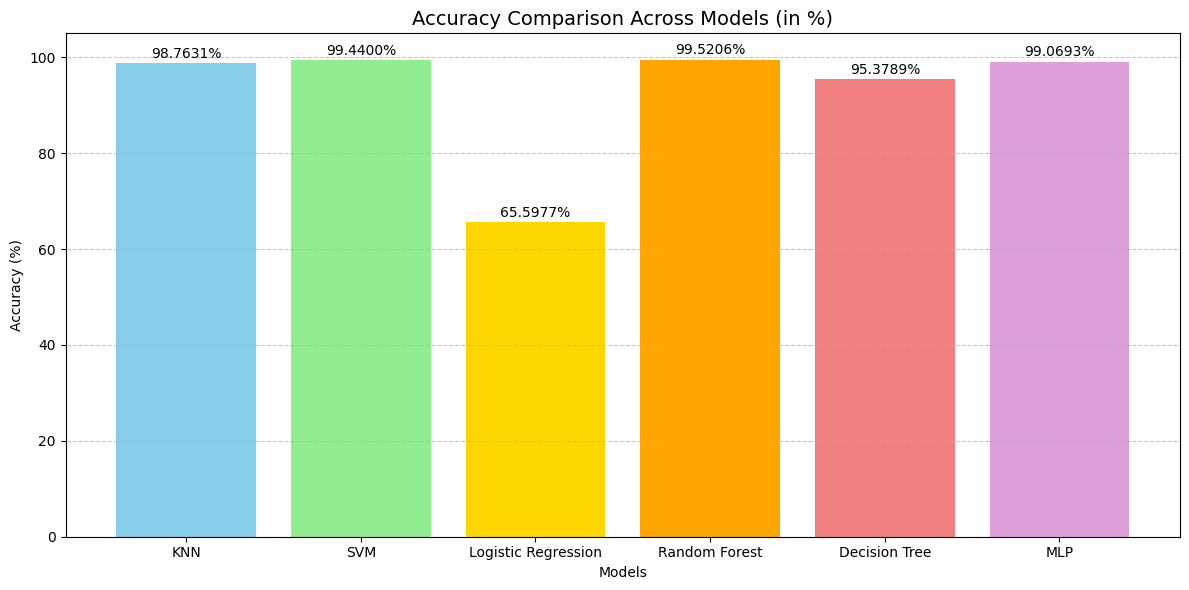

In [48]:
models = ['KNN', 'SVM', 'Logistic Regression', 'Random Forest', 'Decision Tree', 'MLP']
accuracies = [knn_accuracy, svm_accuracy, logistic_predictions, rf_accuracy, dt_accuracy, mlp_accuracy]

plt.figure(figsize=(12, 6))
bars = plt.bar(models, [acc * 100 for acc in accuracies], color=['skyblue', 'lightgreen', 'gold', 'orange', 'lightcoral', 'plum'])

# Annotate percentage accuracy values with 4 decimal places
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.5, f'{yval:.4f}%', ha='center', va='bottom')

plt.title('Accuracy Comparison Across Models (in %)', fontsize=14)
plt.xlabel('Models')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 105)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


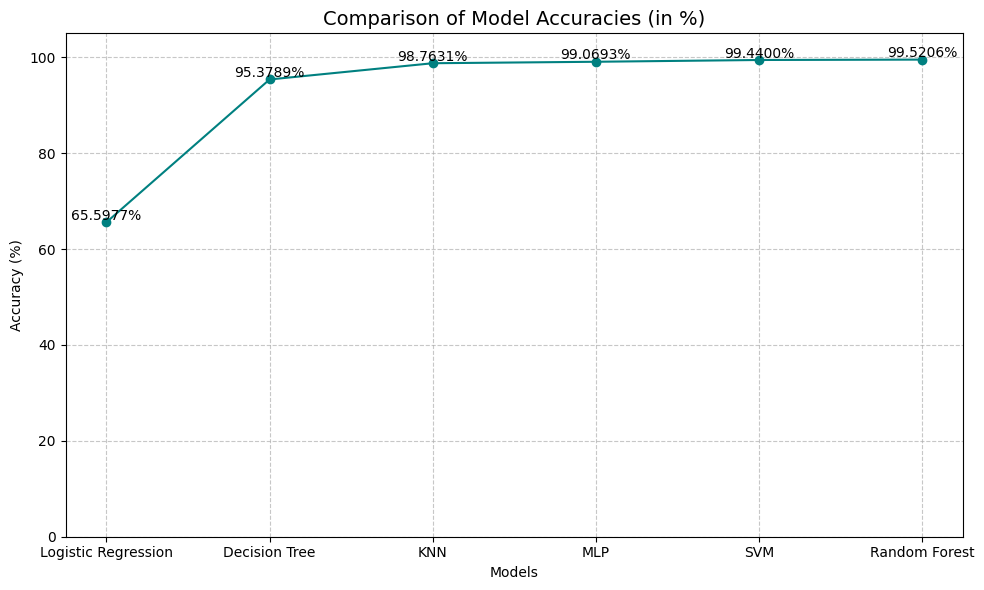

In [51]:
# Zip and sort by accuracy
sorted_models = sorted(zip(models, accuracies), key=lambda x: x[1])
sorted_model_names = [model for model, _ in sorted_models]
sorted_accuracies = [acc for _, acc in sorted_models]

plt.figure(figsize=(10, 6))
plt.plot(sorted_model_names, [acc * 100 for acc in sorted_accuracies], marker='o', linestyle='-', color='teal')

# Annotate each point with percentage
for i, acc in enumerate(sorted_accuracies):
    plt.text(i, acc * 100 + 0.5, f'{acc * 100:.4f}%', ha='center', fontsize=10)

plt.title('Comparison of Model Accuracies (in %)', fontsize=14)
plt.xlabel('Models')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 105)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [53]:
# KNN
knn_predictions = knn.predict(x_test)

# SVM
svm_predictions = svm.predict(x_test)

# Logistic Regression
logistic_predictions = grid_search.predict(x_test)

# Random Forest
rf_predictions = rf.predict(x_test)

# Decision Tree
dt_predictions = dt.predict(x_test)

# MLP
mlp_predictions = mlp.predict(x_test)

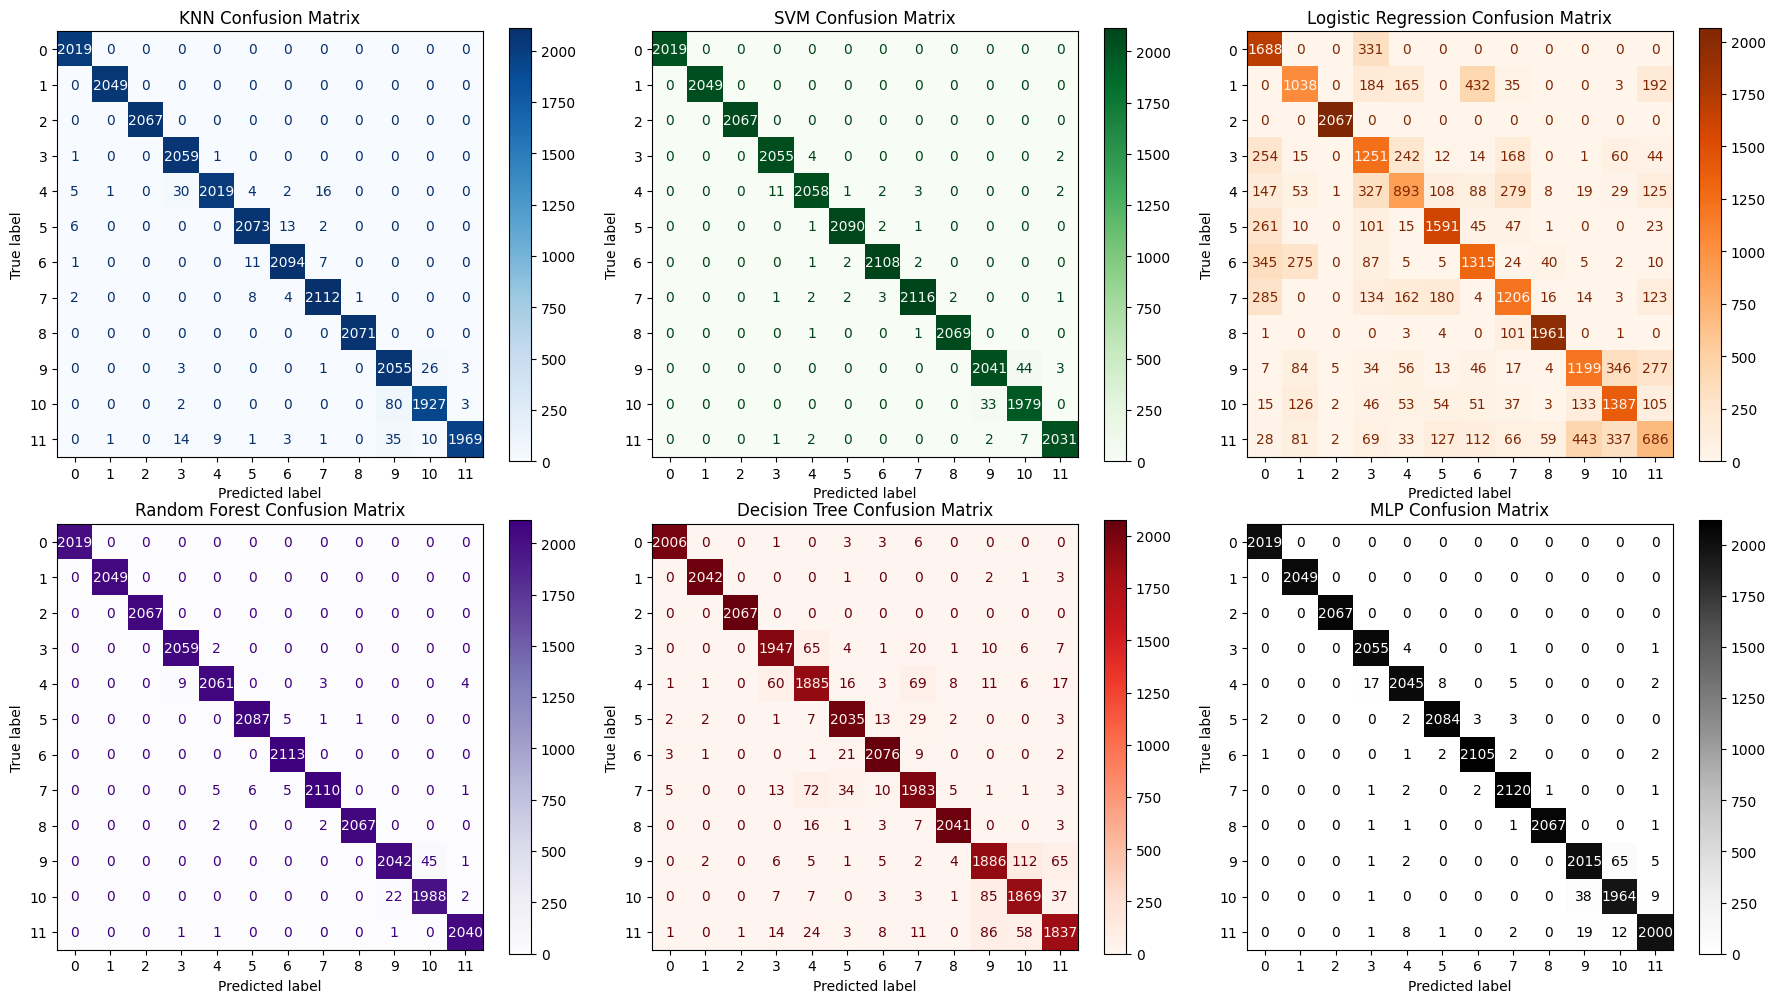

In [54]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
model_names = ['KNN', 'SVM', 'Logistic Regression', 'Random Forest', 'Decision Tree', 'MLP']
predictions = [knn_predictions, svm_predictions, logistic_predictions, rf_predictions, dt_predictions, mlp_predictions]
cmaps = ['Blues', 'Greens', 'Oranges', 'Purples', 'Reds', 'Greys']

for i, (model_name, preds) in enumerate(zip(model_names, predictions)):
    row, col = divmod(i, 3)
    ConfusionMatrixDisplay(confusion_matrix(y_test, preds)).plot(ax=axes[row, col], cmap=cmaps[i])
    axes[row, col].set_title(f'{model_name} Confusion Matrix')

plt.tight_layout()
plt.show()

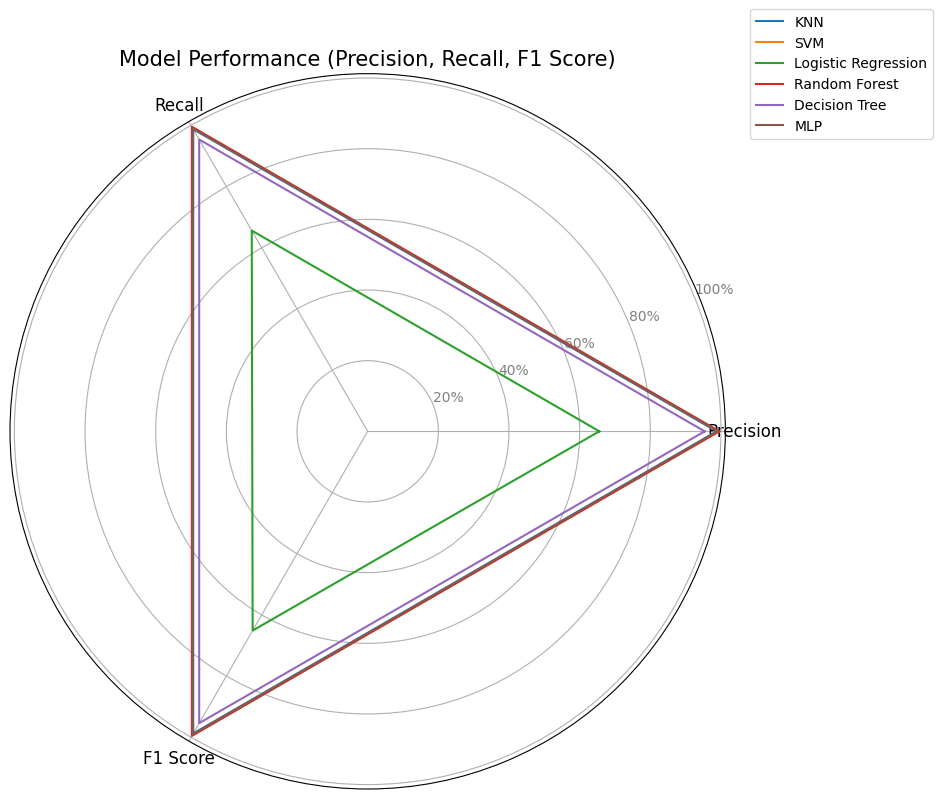

In [56]:
# Compute metrics for each model
metrics = {
    "KNN": [
        precision_score(y_test, knn_predictions, average='macro'),
        recall_score(y_test, knn_predictions, average='macro'),
        f1_score(y_test, knn_predictions, average='macro')
    ],
    "SVM": [
        precision_score(y_test, svm_predictions, average='macro'),
        recall_score(y_test, svm_predictions, average='macro'),
        f1_score(y_test, svm_predictions, average='macro')
    ],
    "Logistic Regression": [
        precision_score(y_test, logistic_predictions, average='macro'),
        recall_score(y_test, logistic_predictions, average='macro'),
        f1_score(y_test, logistic_predictions, average='macro')
    ],
    "Random Forest": [
        precision_score(y_test, rf_predictions, average='macro'),
        recall_score(y_test, rf_predictions, average='macro'),
        f1_score(y_test, rf_predictions, average='macro')
    ],
    "Decision Tree": [
        precision_score(y_test, dt_predictions, average='macro'),
        recall_score(y_test, dt_predictions, average='macro'),
        f1_score(y_test, dt_predictions, average='macro')
    ],
    "MLP": [
        precision_score(y_test, mlp_predictions, average='macro'),
        recall_score(y_test, mlp_predictions, average='macro'),
        f1_score(y_test, mlp_predictions, average='macro')
    ]
}

# Radar chart setup
labels = ['Precision', 'Recall', 'F1 Score']
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]  # to close the loop

plt.figure(figsize=(10, 8))

# Plot each model
for model, scores in metrics.items():
    stats = scores + scores[:1]
    plt.polar(angles, stats, label=model)

plt.xticks(angles[:-1], labels, fontsize=12)
plt.yticks([0.2, 0.4, 0.6, 0.8, 1.0], ["20%", "40%", "60%", "80%", "100%"], color="grey", size=10)
plt.title('Model Performance (Precision, Recall, F1 Score)', size=15)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()


## Making a Hybrid Model
In this section, we explore the creation of a hybrid model by combining the strengths of multiple classifiers. Instead of relying on a single model, hybrid (or ensemble) methods aim to improve overall performance and generalization by aggregating the predictions from multiple models.

In [57]:
hybrid_model = VotingClassifier(
    estimators=[
        ('logreg', lm),
        ('svm', svm),
        ('knn', knn),
        ('rf', rf),
        ('dt', dt),
        ('mlp', mlp)
    ],
    voting='hard'  # Use soft voting since we enabled probabilities
)

In [58]:
hybrid_model.fit(x_train, y_train)

VotingClassifier(estimators=[('logreg',
                              LogisticRegression(multi_class='ovr',
                                                 solver='liblinear')),
                             ('svm', SVC(C=100, probability=True)),
                             ('knn', KNeighborsClassifier(n_neighbors=3)),
                             ('rf', RandomForestClassifier(random_state=42)),
                             ('dt', DecisionTreeClassifier(random_state=42)),
                             ('mlp',
                              MLPClassifier(max_iter=300, random_state=42))])

In [59]:
y_pred = hybrid_model.predict(x_test)
print("Hybrid Model Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, zero_division=0))

Hybrid Model Accuracy: 0.9961323073204141
              precision    recall  f1-score   support

           1       1.00      1.00      1.00      2019
           2       1.00      1.00      1.00      2049
           3       1.00      1.00      1.00      2067
           4       0.99      1.00      1.00      2061
           5       1.00      0.99      1.00      2077
           6       1.00      1.00      1.00      2094
           7       1.00      1.00      1.00      2113
           8       1.00      1.00      1.00      2127
           9       1.00      1.00      1.00      2071
          10       0.98      0.99      0.99      2088
          11       0.99      0.99      0.99      2012
          12       1.00      0.99      1.00      2043

    accuracy                           1.00     24821
   macro avg       1.00      1.00      1.00     24821
weighted avg       1.00      1.00      1.00     24821



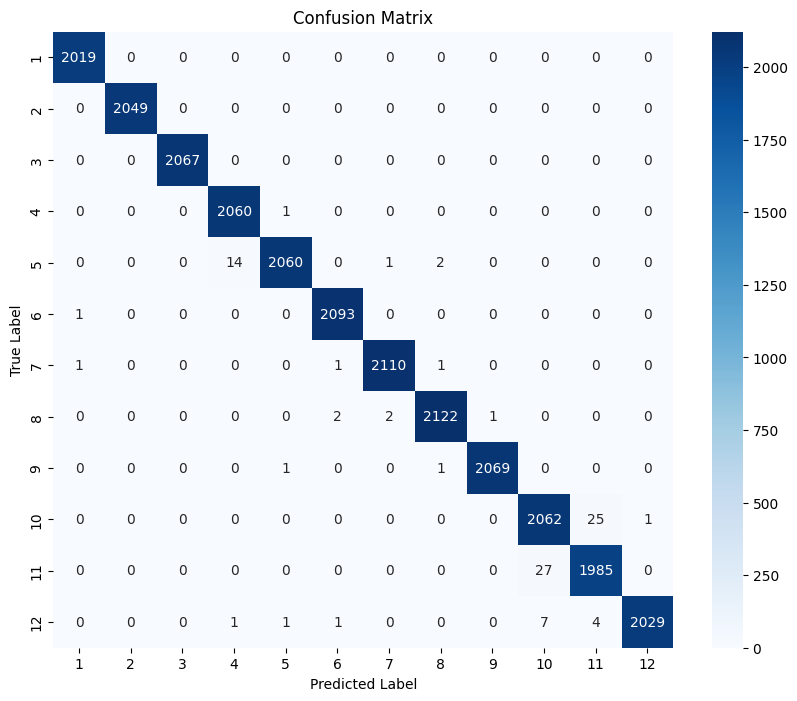

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(1, 13), yticklabels=range(1, 13))
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

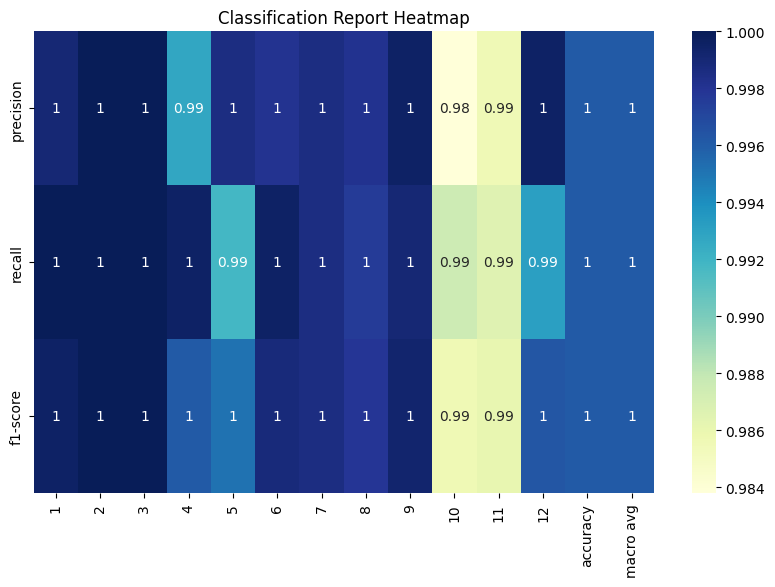

In [61]:
# Classification Report Heatmap
report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
df_report = pd.DataFrame(report).iloc[:-1, :-1]  # remove 'accuracy', 'macro avg', 'weighted avg'
plt.figure(figsize=(10, 6))
sns.heatmap(df_report, annot=True, cmap='YlGnBu')
plt.title("Classification Report Heatmap")
plt.show()


In [63]:
# Save model
joblib.dump(hybrid_model, 'hybrid_model.pkl')

# Save scaler
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']